<a href="https://colab.research.google.com/github/AbdelrahmanSallam04/Drowsy_Driver/blob/main/Drowsy_Driver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define your base path
base_dir = '/content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files'

# Function to count files in subfolders
def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only look at the final subdirectories
            print(f"Found {len(files)} files in: {root}")

count_files(base_dir)

Found 456 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/test/active
Found 453 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/test/fatigue
Found 5862 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/train/active
Found 3192 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/train/fatigue
Found 912 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/val/active
Found 912 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/val/fatigue


In [ ]:
import tensorflow as tf

# Configuration
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Standard for models like MobileNetV2 or ResNet
BASE_PATH = '/content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files'

# Create Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, 'train'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, 'val'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, 'test'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Show the class names to verify
class_names = train_ds.class_names
print(f"Detected classes: {class_names}")

Found 9054 files belonging to 2 classes.
Found 1824 files belonging to 2 classes.
Found 909 files belonging to 2 classes.
Detected classes: ['active', 'fatigue']


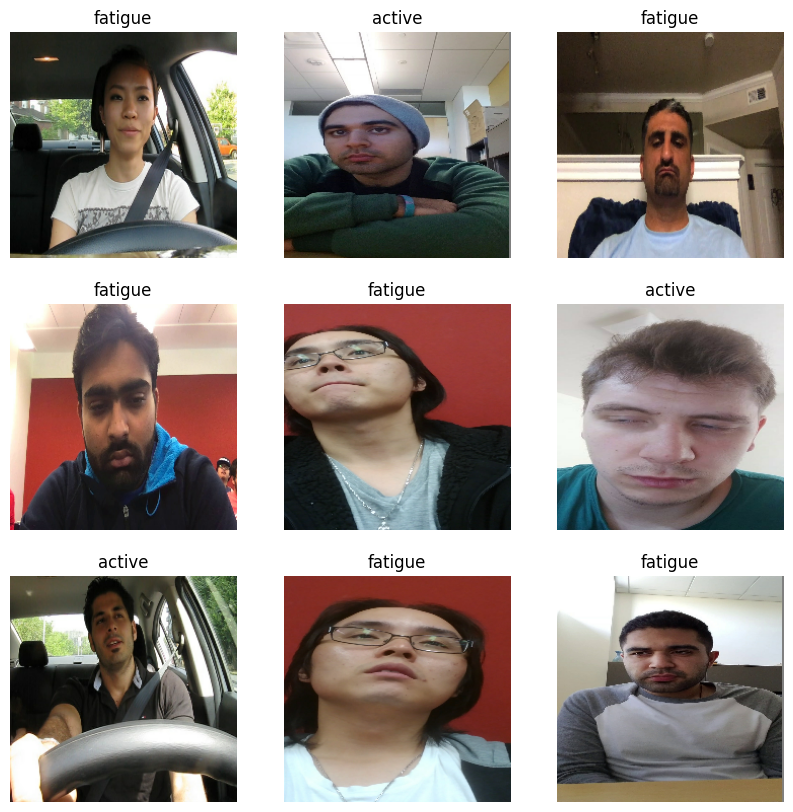

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Replace your manual OpenCV function with this Layer
data_augmentation = tf.keras.Sequential([
    # Flip images to simulate different driver positions (LHD vs RHD)
    layers.RandomFlip("horizontal"),

    # Slight rotation (0.02 = ~7°) to account for head tilting
    layers.RandomRotation(0.02),

    # Adjust brightness (±30%) to simulate different times of day/night driving
    layers.RandomBrightness(0.3),

    # Adjust contrast to help the model find edges in low-light conditions
    layers.RandomContrast(0.3),

    # Shifting the image slightly to make the model robust to camera mounting positions
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
])

# --- APPLYING TO DATASET ---
# We use .map to inject the augmentation logic into the data pipeline.
# 'training=True' ensures augmentation only happens during training, not evaluation.
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# --- OPTIMIZATION ---
# AUTOTUNE allows the CPU to prepare the next batch of images (augmenting/loading)
# while the GPU is training on the current batch.
# This eliminates "bottlenecks" where the GPU is waiting for data.
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

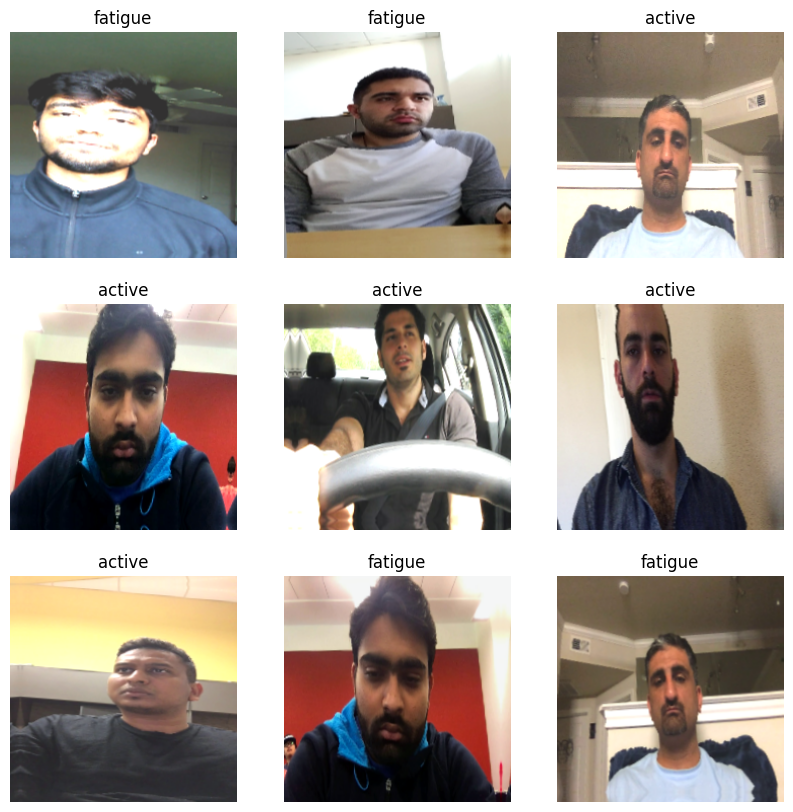

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the Input Shape (must match your dataset image size)
IMG_SHAPE = (224, 224, 3)

# 2. Load the Pre-trained Base (MobileNetV2)
# include_top=False means we throw away the original 1000-class classifier
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

# Freeze the base so we don't destroy the pre-learned features (edges, eyes, etc.)
base_model.trainable = False

# 3. Build the "Head" (The part that decides Active vs. Fatigue)
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Reduces 7x7 map to a single vector
    layers.Dropout(0.2),             # Prevents overfitting (shuts off 20% of neurons randomly)
    layers.Dense(1, activation='sigmoid') # Sigmoid for Binary Classification (0 to 1)
])

# 4. Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# This is where the magic happens
history = model.fit(
    train_ds,              # Your dataset (which ALREADY has the augmentation map attached)
    validation_data=val_ds, # The model uses this to check its progress (no augmentation here!)
    epochs=20              # How many times to repeat the whole process
)

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 911s 3s/step - accuracy: 0.6225 - loss: 0.6613 - val_accuracy: 0.5241 - val_loss: 0.7133
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 199s 701ms/step - accuracy: 0.6373 - loss: 0.6294 - val_accuracy: 0.5044 - val_loss: 0.7773
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 194s 686ms/step - accuracy: 0.6423 - loss: 0.6180 - val_accuracy: 0.5334 - val_loss: 0.7067
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 195s 688ms/step - accuracy: 0.6423 - loss: 0.6085 - val_accuracy: 0.5400 - val_loss: 0.7577
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 206s 701ms/step - accuracy: 0.6420 - loss: 0.6086 - val_accuracy: 0.5768 - val_loss: 0.6499
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 202s 713ms/step - accuracy: 0.6529 - loss: 0.6035 - val_accuracy: 0.5779 - val_loss: 0.6337
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 195s 689ms/step - accuracy: 0.6473 - loss: 0.6062 - val_accuracy: 0.5236 - val_loss: 0.7678
Epoch 8/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 191s 674ms/step - accuracy: 0.6468 - lo

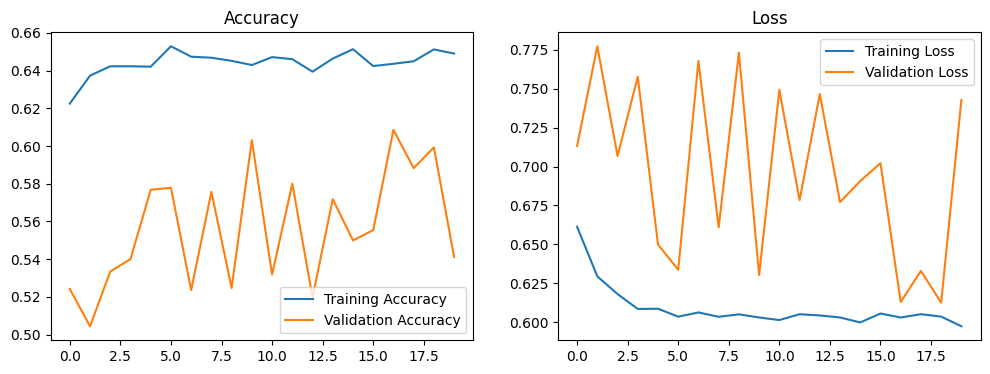

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1] * 100:.2f}%")

29/29 ━━━━━━━━━━━━━━━━━━━━ 169s 6s/step - accuracy: 0.5380 - loss: 0.7415
Test Loss: 0.7415276765823364
Test Accuracy: 53.80%


In [ ]:
# Save in the native Keras format
model.save('/content/drive/MyDrive/DrowsyDriver_Dataset/drowsy_model_v1.keras')
print("Model Saved to Drive!")

Model Saved to Drive!
